In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation
from src.utils.transformation_utils import CoordTransformer
from src.filter.ekf import EKF, MeasurementBlock, FusionData
from src.utils.misc import StationaryDetector
from src.model.imu_noise_net import IMUNoiseNet
from src.utils.dataset import get_kitti_data, KittiData


In [2]:
root_dir = "./data/KITTI"
result_dir = "./results"
is_sync = True

In [3]:
def visualize_trajectories(estimated_trajectory, ground_truth_trajectory):
    plt.figure(figsize=(6, 6))
    plt.plot(ground_truth_trajectory[:, 0], ground_truth_trajectory[:, 1], label='Ground Truth', color='black')
    plt.plot(estimated_trajectory[:, 0], estimated_trajectory[:, 1], label='Dead Reckoning Estimate', color='blue')
    plt.xlabel('X Position (m)')
    plt.ylabel('Y Position (m)')
    plt.title('Trajectory Comparison')
    plt.legend()
    plt.axis('equal')
    plt.grid()
    plt.show()

def run_dead_reckoning_100Hz(kitti_data: KittiData, model_path: str = "./parameters/best_imu_cov_net.pt", device: str = "cpu"):
    position_array_full = kitti_data.positions
    lla_array_full = kitti_data.lla_position
    orientations = kitti_data.orientations
    
    target_timestamps = kitti_data.target_timestamps
    timestamps = kitti_data.timestamps
    imu_windows = kitti_data.imu_windows

    acc_array = kitti_data.acc
    gyro_array = kitti_data.gyro
    position_array = position_array_full

    transformer: CoordTransformer = kitti_data.transformer

    stationary_detector = StationaryDetector(
        acc_threshold=0.05, 
        gyro_threshold=0.005,
        min_stationary_samples=10
    )

    ekf = EKF()

    p0 = kitti_data.initial_position
    v_body = kitti_data.initial_velocity
    euler0 = kitti_data.initial_orientation
    q0 = Rotation.from_euler('xyz', euler0).as_quat(scalar_first=True)
    R0 = Rotation.from_quat(q0, scalar_first=True).as_matrix()
    v0 = R0 @ v_body
    ekf.init_state(p0, v0, q0)

    model = IMUNoiseNet().to(device)
    model_params = torch.load(model_path, map_location=device)
    model.load_state_dict(model_params["model_state"])
    model.eval()

    lla_estimated_list = []
    estimated_trajectory = []

    estimated_orientation = []
    ground_truth_orientation = []

    z_lu = np.zeros(2)
    z_v0 = np.zeros(3)
    R_v0 = np.eye(3) * 1.0

    dt_seq = [
        (target_timestamps[k] - timestamps[k]).total_seconds()
        for k in range(len(imu_windows))
    ]

    
    for i in range(len(imu_windows)):
        acc = acc_array[i]
        gyro = gyro_array[i]

        timestamp = timestamps[i]
        dt = dt_seq[i]
        
        ekf.predict(acc, gyro, dt=dt, timestamp=timestamp.timestamp())
        
        is_stationary = stationary_detector.is_stationary(acc, gyro, timestamp)

        mask_no_bias = np.ones(16)
        mask_no_bias[10:16] = 0.0
        if is_stationary:
            block = MeasurementBlock.from_measurement_type(
                FusionData.LINEAR_VELOCITY,
                z=z_v0,
                R=R_v0,
                mask=mask_no_bias,
            )
        else:
            imu_buffer = torch.tensor(imu_windows[i], dtype=torch.float32).unsqueeze(0).to(device)
            R_lu = model(imu_buffer).cpu().detach().numpy().squeeze(0)
            block = MeasurementBlock.from_measurement_type(
                FusionData.VELOCITY_CONSTRAINT,
                z=z_lu,
                R=R_lu,
                mask=mask_no_bias,
            )
        
        ekf.correct(blocks=[block], timestamp=timestamp.timestamp())

        estimated_position = ekf.x[0:3].copy()
        lla_dead_reckoning = transformer.transform_to_lla(estimated_position)

        estimated_euler = Rotation.from_quat(ekf.x[6:10].copy(), scalar_first=True).as_euler('xyz')
        estimated_orientation.append(estimated_euler)
        ground_truth_orientation.append(orientations[i])

        lla_estimated_list.append(lla_dead_reckoning)
        estimated_trajectory.append(estimated_position)
    
    lla_estimated_array = np.array(lla_estimated_list)
    estimated_trajectory_array = np.array(estimated_trajectory)
    estimated_orientation_array = np.array(estimated_orientation)
    ground_truth_orientation_array = np.array(ground_truth_orientation)

    return {
        "lla_estimated": lla_estimated_array,
        "estimated_trajectory": estimated_trajectory_array,
        "lla_ground_truth": lla_array_full,
        "ground_truth_trajectory": position_array,
        "estimated_orientation": estimated_orientation_array,
        "ground_truth_orientation": ground_truth_orientation_array
    }



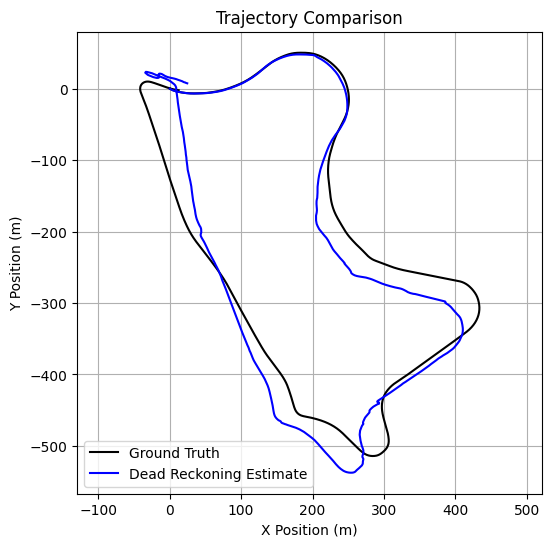

In [4]:
seq = "09"
seq09_data = get_kitti_data(seq, root_dir, is_sync=False)
result_seq09 = run_dead_reckoning_100Hz(seq09_data)
visualize_trajectories(result_seq09["estimated_trajectory"], result_seq09["ground_truth_trajectory"])

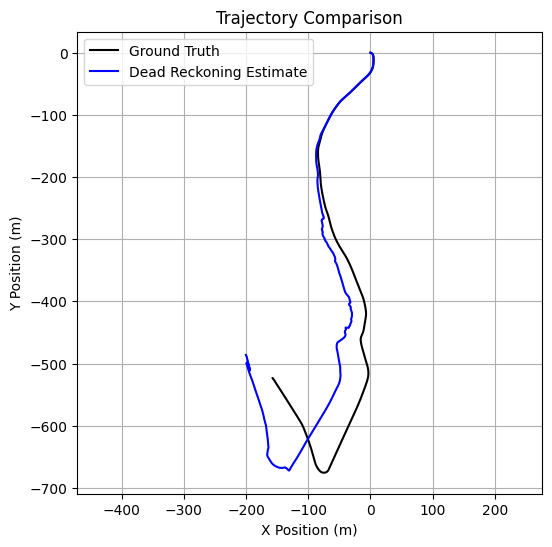

In [5]:
seq = "10"
seq10_data = get_kitti_data(seq, root_dir, is_sync=False)

result_seq10 = run_dead_reckoning_100Hz(seq10_data)
visualize_trajectories(result_seq10["estimated_trajectory"], result_seq10["ground_truth_trajectory"])

## Save the results

In [6]:
seq09_result_dir = os.path.join(result_dir, "09", "ml_enhanced_dead_reckoning.npz")
seq10_result_dir = os.path.join(result_dir, "10", "ml_enhanced_dead_reckoning.npz")

np.savez(seq09_result_dir, **result_seq09)
np.savez(seq10_result_dir, **result_seq10)